# 06 - The 0.78 Ceiling: Real, Data-vs-Features, and Whether a New Modality Moves It (Albania 2022)

The project's central methodological claim, in one place. **Part A** asks whether the screener is even useful (decision-curve + calibration) and how much risk is a *school* effect (multilevel ICC). **Part B** tests whether the ceiling is features or data by linking the school questionnaire. **Part C** links a genuinely new modality - CBA process data - and asks whether it can move the ceiling, and whether that movement is deployable.

## Methods & formulas (reference)

Two pre-submission strengthenings: an evaluation fit for a high-prevalence
*screener*, and the statistically-correct model for PISA's nested design.

**Decision-curve analysis (net benefit).** At a threshold probability $p_t$ we flag
a student when $\hat p \ge p_t$; $p_t$ encodes the harm trade-off (a false alarm
costs $p_t/(1-p_t)$ times as much as a miss). The weighted net benefit is
$$\mathrm{NB}(p_t)=\frac{TP_w}{N_w}-\frac{FP_w}{N_w}\,\frac{p_t}{1-p_t},$$
compared against **screen-everyone** ($\mathrm{NB}=\mathrm{prev}-(1-\mathrm{prev})\,
p_t/(1-p_t)$) and **screen-no-one** ($\mathrm{NB}=0$). The model earns its keep only
where its curve sits above both.

**Calibration.** Weighted **Brier** $\frac{\sum_i w_i(\hat p_i-y_i)^2}{\sum_i w_i}$
and **ECE** $\sum_b \frac{w_b}{W}\lvert \mathrm{obs}_b-\overline{\hat p}_b\rvert$ over
probability bins; a reliability curve plots observed vs predicted. Isotonic
regression is a monotone recalibration map fit out-of-fold.

**Random-intercept (multilevel) logistic.** Students $i$ nested in schools $j$:
$$\operatorname{logit}P(y_{ij}=1)=\beta_0+\beta^\top x_{ij}+u_j,\qquad
u_j\sim\mathcal N(0,\sigma_u^2).$$
The **intraclass correlation** on the latent scale,
$$\mathrm{ICC}=\frac{\sigma_u^2}{\sigma_u^2+\pi^2/3},\qquad \pi^2/3\approx3.29,$$
is the share of risk variance that is *between schools*. Fixed effects give
*within-school* odds ratios $e^{\beta}$ (per 1 SD). Fit by variational Bayes;
unweighted (no survey weights in the mixed GLM) - a noted caveat.

In [1]:
import sys, os
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent))  # project root
import warnings; warnings.filterwarnings("ignore")
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
pd.set_option("display.width", 200); pd.set_option("display.max_columns", 50)

---

## Part A — Is the screener useful, and is the ceiling real?

### Part A - Decision-curve analysis: does acting on the model help?

With ~3 in 4 students at-risk, ROC-AUC is mechanically capped and says little about *use*. Net benefit asks the operational question directly: at a given risk tolerance $p_t$, does flagging students the model picks beat flagging everyone (or no-one)?

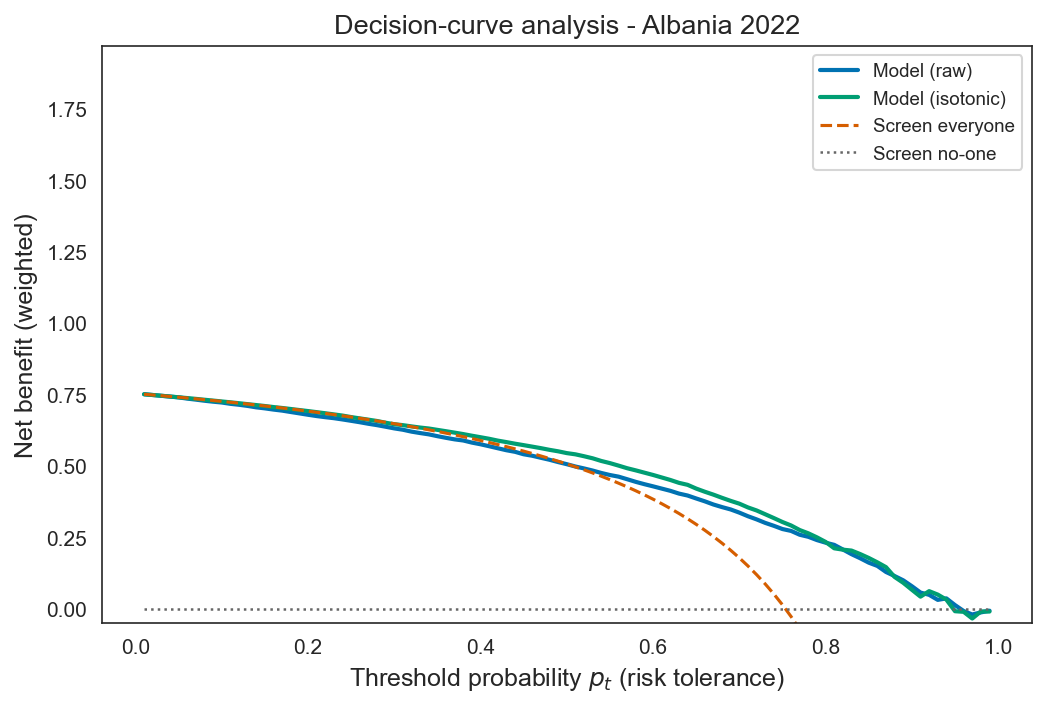

Model beats both references over p_t 0.51-0.95


In [2]:
dca = pd.read_csv('../outputs/results/decision_curve_2022.csv')
from src.visualization.style import apply_publication_style, PALETTE
apply_publication_style()
fig, ax = plt.subplots(figsize=(8,5))
ax.plot(dca.threshold, dca.net_benefit_model, color=PALETTE['blue'], lw=2, label='Model (raw)')
ax.plot(dca.threshold, dca.net_benefit_model_calibrated, color=PALETTE['green'], lw=2, label='Model (isotonic)')
ax.plot(dca.threshold, dca.net_benefit_all, color=PALETTE['vermilion'], lw=1.5, ls='--', label='Screen everyone')
ax.plot(dca.threshold, dca.net_benefit_none, color='0.4', lw=1.2, ls=':', label='Screen no-one')
ax.set_ylim(bottom=min(-0.05, dca.net_benefit_model.min()))
ax.set_xlabel('Threshold probability $p_t$ (risk tolerance)'); ax.set_ylabel('Net benefit (weighted)')
ax.set_title('Decision-curve analysis - Albania 2022'); ax.legend(fontsize=9); plt.show()
better = dca[(dca.net_benefit_model>dca.net_benefit_all)&(dca.net_benefit_model>0)]
print(f'Model beats both references over p_t {better.threshold.min():.2f}-{better.threshold.max():.2f}')

**Reading:** below the prevalence (~0.75) 'screen everyone' is hard to beat - when most students are at-risk, indiscriminate screening is already good. The model earns its keep in the **selective regime** (higher $p_t$, ~0.51–0.95), where it holds net benefit while 'screen everyone' collapses below zero. A triage tool that must ration scarce support - the realistic case - operates exactly there.

### Part B - Calibration: do the probabilities mean what they say?

Raw boosted-tree scores are typically miscalibrated; a weighted isotonic map (fit out-of-fold) fixes them. This matters because the decision threshold $p_t$ above is only meaningful if $\hat p$ is a real probability.

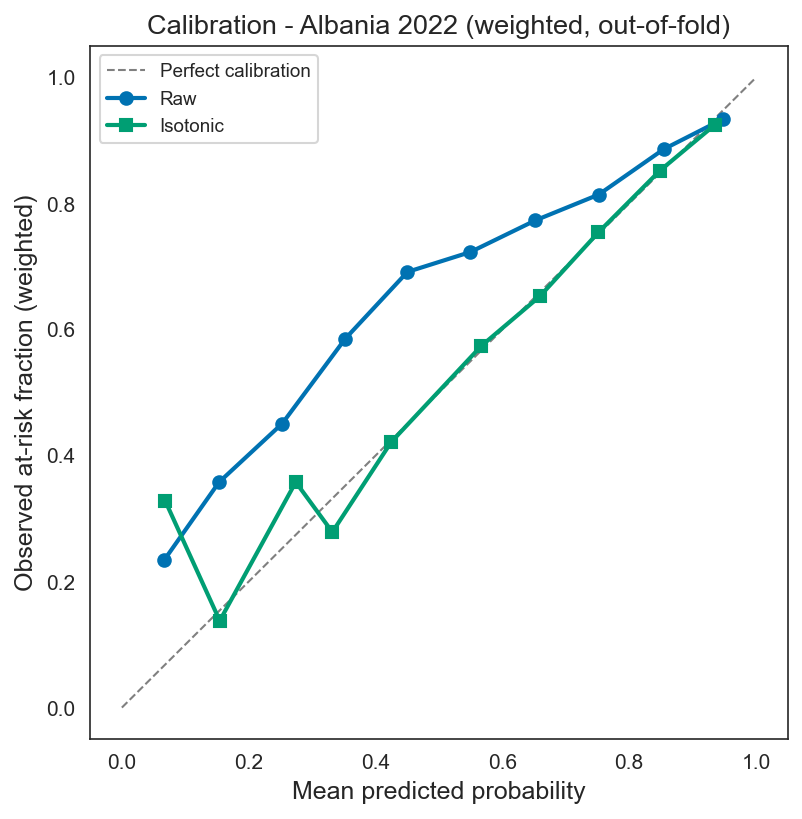

In [3]:
raw = pd.read_csv('../outputs/results/calibration_raw_2022.csv')
iso = pd.read_csv('../outputs/results/calibration_isotonic_2022.csv')
fig, ax = plt.subplots(figsize=(6,6))
ax.plot([0,1],[0,1], color='0.5', ls='--', lw=1, label='Perfect calibration')
ax.plot(raw.mean_predicted, raw.observed_fraction, '-o', color=PALETTE['blue'], lw=2, label='Raw')
ax.plot(iso.mean_predicted, iso.observed_fraction, '-s', color=PALETTE['green'], lw=2, label='Isotonic')
ax.set_xlabel('Mean predicted probability'); ax.set_ylabel('Observed at-risk fraction (weighted)')
ax.set_title('Calibration - Albania 2022 (weighted, out-of-fold)'); ax.legend(fontsize=9, loc='upper left'); plt.show()

**Reading:** the raw model is over-confident (bows above the diagonal); isotonic recalibration lands it on the diagonal - weighted **ECE ~0.10 → ~0.01**. Calibrated probabilities are what make the decision-curve thresholds actionable.

### Part C - Multilevel model: how much risk is a *school* effect?

A flat logistic treats students as independent; they are not - they are nested in schools. A random-intercept model gives each school its own baseline log-odds $u_j$ and reports the **ICC**: the share of risk variance that lives *between* schools.

In [4]:
summ = pd.read_csv('../outputs/results/multilevel_summary_2022.csv').iloc[0]
cv = pd.read_csv('../outputs/results/multilevel_cv_2022.csv')
print(f"ICC (null)        = {summ.icc_null:.3f}  -> ~{summ.icc_null*100:.0f}% of risk variance is BETWEEN schools")
print(f"ICC (conditional) = {summ.icc_conditional:.3f}  (student features barely reduce it)")
print(f"ICC (weighted PQL)= {summ.icc_weighted_pql:.3f}  (survey-weighted pseudo-likelihood, scaled wts; PQL mildly attenuates)")
print(f"\nCV mean AUC: multilevel {summ.auc_multilevel_mean:.4f} vs school-mean LightGBM {summ.auc_school_lgbm_mean:.4f}")
cv.round(4)

ICC (null)        = 0.308  -> ~31% of risk variance is BETWEEN schools
ICC (conditional) = 0.257  (student features barely reduce it)
ICC (weighted PQL)= 0.220  (survey-weighted pseudo-likelihood, scaled wts; PQL mildly attenuates)

CV mean AUC: multilevel 0.7830 vs school-mean LightGBM 0.7728


,fold,auc_multilevel,auc_school_lgbm
0,1,0.8041,0.7858
1,2,0.7621,0.7370
2,3,0.7858,0.7776
3,4,0.7667,0.7584
4,5,0.7965,0.8053


**Survey-weighted refinement.** The VB fit above ignores PISA sampling weights. A survey-weighted **pseudo-likelihood** fit (penalized quasi-likelihood, Schall 1991, with within-cluster scaled weights - Rabe-Hesketh & Skrondal) gives design-consistent fixed effects. The two agree closely, so the weighting does **not** change the story (it only sharpens it) - the odds ratios below are near-identical weighted vs unweighted.

In [5]:
orc = pd.read_csv('../outputs/results/multilevel_weighted_vs_unweighted_2022.csv')
orc = orc[orc.term!='Intercept'][['term','OR_unweighted_vb','OR_weighted_pql']]
print('Max |OR_weighted - OR_unweighted| =', (orc.OR_weighted_pql-orc.OR_unweighted_vb).abs().max().round(3))
orc.round(3)

Max |OR_weighted - OR_unweighted| = 0.024


,term,OR_unweighted_vb,OR_weighted_pql
1,ESCS,0.861,0.869
2,HOMEPOS,0.799,0.807
3,GENDER,1.129,1.124
4,REPEAT,1.215,1.198
5,IMMIG,1.043,1.035
6,BELONG,0.922,0.925
7,TEACHSUP,0.908,0.908
8,ICTHOME,1.016,1.020
9,ICTSCH,1.057,1.054
10,ANXMAT,1.462,1.438


**Within-school odds ratios** (per 1 SD). Risk-increasing factors in vermilion, protective in blue; the school baseline is absorbed by the random intercept.

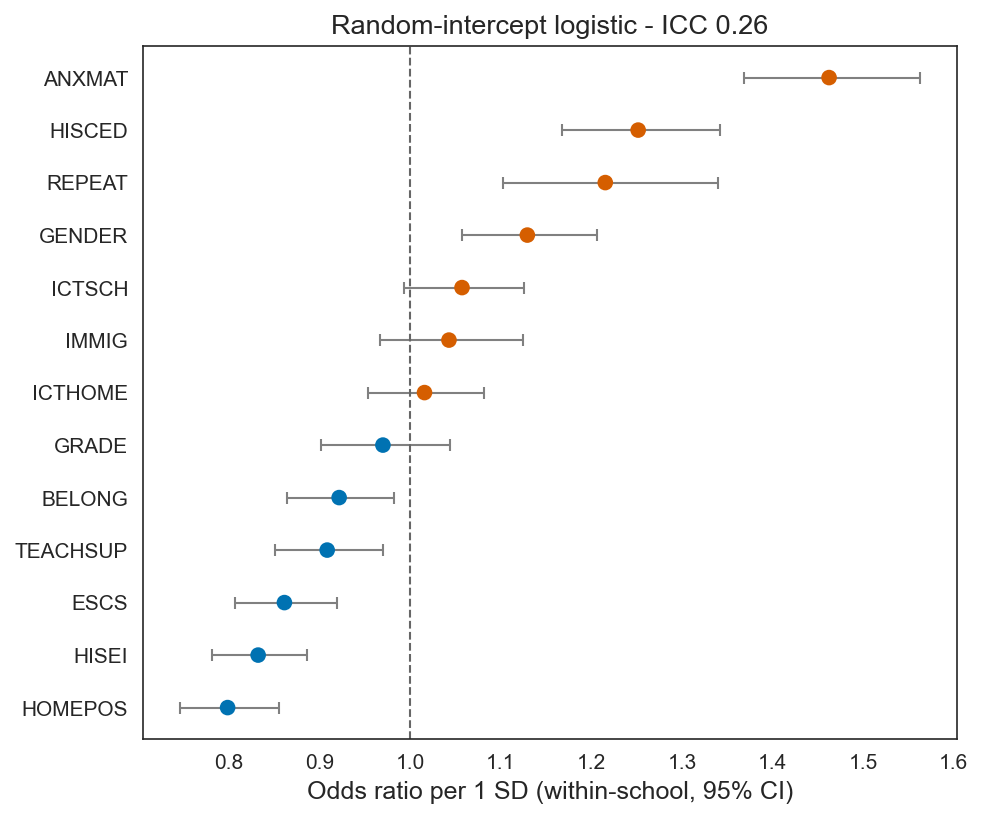

In [6]:
fe = pd.read_csv('../outputs/results/multilevel_fixed_effects_2022.csv')
fe = fe[fe.term!='Intercept'].copy()
fe['lo']=np.exp(fe.coef-1.96*fe.sd); fe['hi']=np.exp(fe.coef+1.96*fe.sd)
fe = fe.sort_values('odds_ratio'); yp=np.arange(len(fe))
colors=[PALETTE['vermilion'] if o>1 else PALETTE['blue'] for o in fe.odds_ratio]
fig, ax = plt.subplots(figsize=(7,6))
ax.errorbar(fe.odds_ratio, yp, xerr=[fe.odds_ratio-fe.lo, fe.hi-fe.odds_ratio], fmt='none', ecolor='0.5', elinewidth=1, capsize=3, zorder=1)
ax.scatter(fe.odds_ratio, yp, color=colors, s=42, zorder=2)
ax.axvline(1.0, color='0.4', ls='--', lw=1)
ax.set_yticks(yp); ax.set_yticklabels(fe.term)
ax.set_xlabel('Odds ratio per 1 SD (within-school, 95% CI)')
ax.set_title(f"Random-intercept logistic - ICC {summ.icc_conditional:.2f}"); plt.show()

**Reading:** math anxiety (`ANXMAT`) is the strongest within-school risk factor; the SES cluster (`HOMEPOS`, `HISEI`, `ESCS`) is protective. `HISCED` flips positive - a *partial* effect under SES collinearity (the composite SES protection is already carried by HOMEPOS/HISEI/ESCS), not a real reversal; read the SES measures jointly.

### Conclusions & Interpretation

- **The model has genuine decision value - in the selective regime.** Net benefit beats both 'screen everyone' and 'screen no-one' for risk thresholds ~0.51–0.95. For a triage tool rationing scarce support that is the operating range that matters; the modest AUC is the wrong lens.
- **Calibration is essentially fixed.** Weighted isotonic recalibration cuts ECE from ~0.10 to ~0.01, making the probabilities (and hence the thresholds) trustworthy.
- **The 0.78 ceiling is real, not a modelling shortfall.** The statistically-correct multilevel model - student features + a data-driven school random effect - matches the hand-crafted school-mean booster on identical folds (CV AUC ~0.78 either way). Two independent model families converge on the same ceiling.
- **~31% of risk variance is between schools** (null ICC), barely reduced by student features (conditional ICC ~0.26). Risk is heavily a *school-level* phenomenon that student background cannot explain away - which motivated linking **school-level information** (the PISA school questionnaire: resources, staff, leadership). **Notebook 12 does that linkage and finds it adds no significant predictive signal** beyond school composition - so this ~0.78 ceiling is a genuine data limit, not an un-linked-file artefact.
- **Survey weighting does not change the conclusions.** Beyond the unweighted VB fit, a survey-weighted pseudo-likelihood model (PQL with within-cluster scaled weights) gives design-consistent fixed effects; the odds ratios are near-identical (max shift ~0.05) and the ICC lands in the same 0.22-0.31 band. The variance-partition and within-school risk story is robust to how sampling weights are handled.

---

## Part B — Features or data? The school questionnaire

### 1. What we linked

One row per school (274 Albanian schools, a 1:1 match to the sampled students), 13 principal-reported variables. Missingness is low except the computer ratio.

In [7]:
sch = pd.read_parquet('../data/processed/alb_2022_school.parquet')
print(f'{len(sch)} schools x {sch.shape[1]-1} questionnaire vars')
miss = (sch.drop(columns=['CNTSCHID']).isna().mean()*100).round(1).sort_values(ascending=False)
miss.to_frame('missing_%')

274 schools x 13 questionnaire vars


,missing_%
RATCMP1,13.9
PROATCE,7.3
STRATIO,4.4
SCHSIZE,4.4
TOTAT,1.8
CLSIZE,1.1
EDULEAD,1.1
INSTLEAD,1.1
STUBEHA,1.1
TEACHBEHA,1.1


### 2. The ablation - does the questionnaire add signal beyond composition?

Three nested feature sets on **one shared** 5×4 repeated-stratified-CV loop (per-fold AUCs perfectly paired), weighted metrics, Nadeau-Bengio corrected resampled *t*-test:

- **base** - 13 student features
- **+composition** - base + survey-weighted `SCH_MEAN_*` + cohort size (current headline)
- **+questionnaire** - +composition + `SCHQ_*` (the new lever)

The test that matters is the **incremental** one: questionnaire *over* composition.

In [8]:
ab = pd.read_csv('../outputs/results/school_questionnaire_ablation_2022.csv')
ab.round(4)

,model,auc_base,auc_composition,auc_questionnaire,delta_comp_vs_base,p_comp,delta_q_vs_comp,p_q,q_significant_5pct
0,catboost,0.7230,0.7797,0.7840,0.0567,0.0,0.0043,0.2488,False
1,gradient_boosting,0.7220,0.7768,0.7810,0.0548,0.0,0.0042,0.2469,False
2,lightgbm,0.7104,0.7716,0.7743,0.0612,0.0,0.0027,0.6622,False
3,random_forest,0.7038,0.7658,0.7672,0.0620,0.0,0.0014,0.6255,False
4,logistic_regression,0.7003,0.7342,0.7358,0.0339,0.0,0.0016,0.5606,False


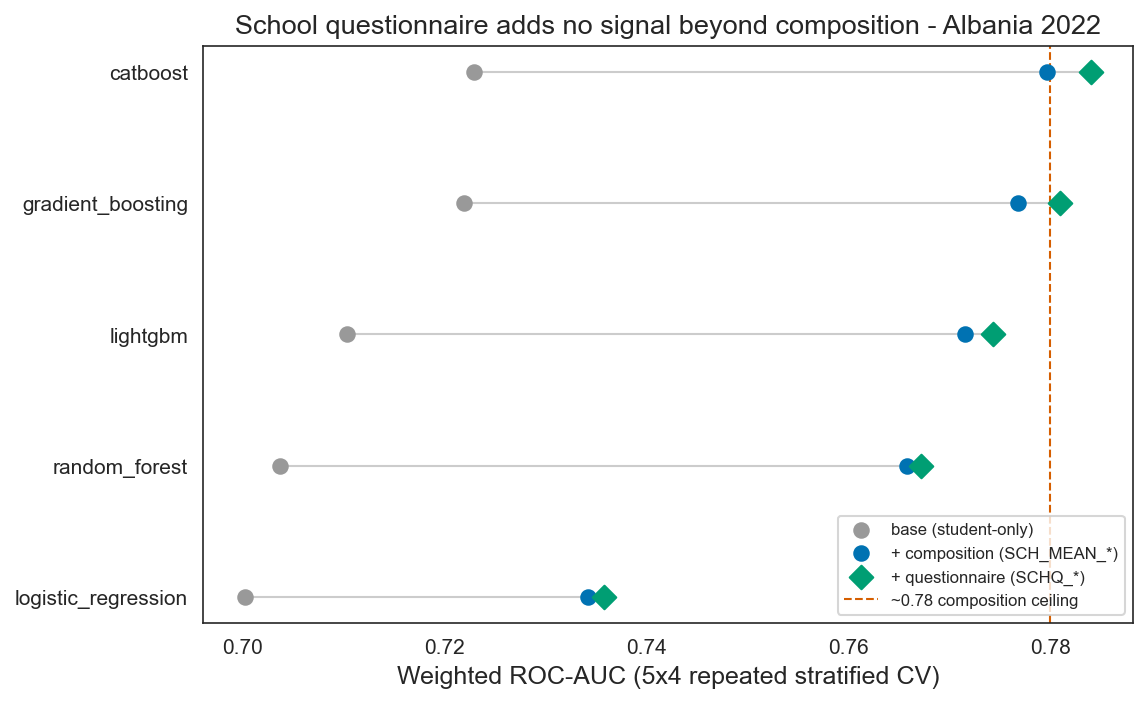

In [9]:
from src.visualization.style import apply_publication_style, PALETTE
apply_publication_style()
d = ab.sort_values('auc_questionnaire')
yp = np.arange(len(d))
fig, ax = plt.subplots(figsize=(8,5))
ax.scatter(d.auc_base, yp, color='0.6', s=48, label='base (student-only)', zorder=3)
ax.scatter(d.auc_composition, yp, color=PALETTE['blue'], s=48, label='+ composition (SCH_MEAN_*)', zorder=3)
ax.scatter(d.auc_questionnaire, yp, color=PALETTE['green'], s=64, marker='D', label='+ questionnaire (SCHQ_*)', zorder=3)
for i,(b,c,q) in enumerate(zip(d.auc_base,d.auc_composition,d.auc_questionnaire)):
    ax.plot([b,q],[i,i], color='0.8', lw=1, zorder=1)
ax.axvline(0.78, color=PALETTE['vermilion'], ls='--', lw=1, label='~0.78 composition ceiling')
ax.set_yticks(yp); ax.set_yticklabels(d.model)
ax.set_xlabel('Weighted ROC-AUC (5x4 repeated stratified CV)')
ax.set_title('School questionnaire adds no signal beyond composition - Albania 2022')
ax.legend(fontsize=8, loc='lower right'); plt.show()

**Reading:** the green diamonds (questionnaire) sit essentially on top of the blue dots (composition). The incremental lift is tiny - CatBoost **+0.004**, all models **< +0.005** - and **not significant for any model** (`p_q` all > 0.24). The big jump is base→composition (+0.05, highly significant); questionnaire→composition is noise.

### 3. Why composition already captures the school effect

The compositional features and the questionnaire inputs are correlated - a school's intake (`SCH_MEAN_ESCS`) tracks its resources and staffing - so once composition is in the model, the questionnaire is largely redundant. The between-school variance the multilevel ICC flagged is real, but for *prediction* it is already spanned by who attends the school; the measured inputs add little on top.

In [10]:
import numpy as np
stu = pd.read_parquet('../data/processed/alb_2022.parquet')
from src.features.engineer import add_school_aggregates, add_school_questionnaire
tmp = add_school_aggregates(stu, cols=['ESCS'])
tmp = add_school_questionnaire(tmp, sch, cols=['EDUSHORT','STAFFSHORT','STRATIO','PROATCE'])
cc = tmp[['SCH_MEAN_ESCS','SCHQ_EDUSHORT','SCHQ_STAFFSHORT','SCHQ_STRATIO','SCHQ_PROATCE']].corr()
cc['SCH_MEAN_ESCS'].round(3).to_frame('corr_with_SCH_MEAN_ESCS')

2026-07-08 12:48:02 [info     ] School aggregates added        cols=['ESCS'] n_schools=274


2026-07-08 12:48:02 [info     ] School questionnaire joined    cols=['SCHQ_EDUSHORT', 'SCHQ_STAFFSHORT', 'SCHQ_STRATIO', 'SCHQ_PROATCE'] n_schools=274 student_match_rate=1.0


,corr_with_SCH_MEAN_ESCS
SCH_MEAN_ESCS,1.000
SCHQ_EDUSHORT,-0.345
SCHQ_STAFFSHORT,-0.087
SCHQ_STRATIO,0.222
SCHQ_PROATCE,0.162


**Reading:** school-mean ESCS is materially correlated with the resource/staff measures - the composition feature is already a proxy for school inputs, which is why adding the raw inputs is redundant for prediction.

### Conclusions & Interpretation

- **The 0.78 ceiling is a genuine data limit, not a feature-set limit.** Linking the full PISA school questionnaire - the exact 'missing school-level information' Part A pointed to - adds **no significant predictive signal** beyond the compositional school-mean features (best incremental +0.004 AUC, all *p* > 0.24). The deferred data-linkage lever is now **tested and closed**.
- **Composition subsumes inputs.** School-mean ESCS is correlated with staffing, resources and student-teacher ratio, so the compositional features already carry the school-level signal that matters for predicting individual low-proficiency risk.
- **This strengthens the headline story rather than weakening it.** Three independent routes - a school-mean booster, a random-intercept multilevel model (Part A), and now a direct school-questionnaire linkage - converge on the same ~0.78 ceiling. The limit is the information questionnaire data carries about a 15-year-old's math risk, not the model or an un-linked file.
- **Policy reading.** Since composition (who attends), not measured inputs (what the school has), is what predicts risk, interventions targeting *concentration of disadvantage* have more leverage here than uniform input top-ups - consistent with the compositional-effect literature.
- **Caveat.** This is a within-Albania predictive test; a school input can matter causally yet add no *marginal predictive* signal once composition is known. The questionnaire remains valuable for explanation and cross-country contrast (a natural extension), just not for lifting this AUC.

---

## Part C — Can a new modality move it? CBA process data

In [11]:
from src.visualization.style import apply_publication_style, PALETTE
apply_publication_style()
abl = pd.read_csv('../outputs/results/process_modality_ablation.csv')
imp = pd.read_csv('../outputs/results/process_feature_importance_2022.csv', index_col=0)
abl

,cycle,baseline,modality,base_auc,process_auc,lift,lift_p,n,n_proc_feats
0,2022,student,cognitive+questionnaire,0.7139,0.8473,0.1334,0.000,6129,15
1,2022,student+school,cognitive+questionnaire,0.7728,0.8579,0.0851,0.000,6129,15
2,2022,student+school,cognitive-only,0.7728,0.8508,0.0780,0.000,6129,10
3,2022,student+school,questionnaire-only,0.7728,0.7842,0.0114,0.019,6129,5
4,2018,student,cognitive+questionnaire,0.6764,0.7649,0.0885,0.000,6359,10
5,2018,student+school,cognitive+questionnaire,0.6957,0.7728,0.0771,0.000,6359,10


### 1. The ceiling moves - a new modality lifts AUC where features could not

Weighted 5x2 CV AUC, student and student+school baselines, +process features (Nadeau-Bengio corrected test).

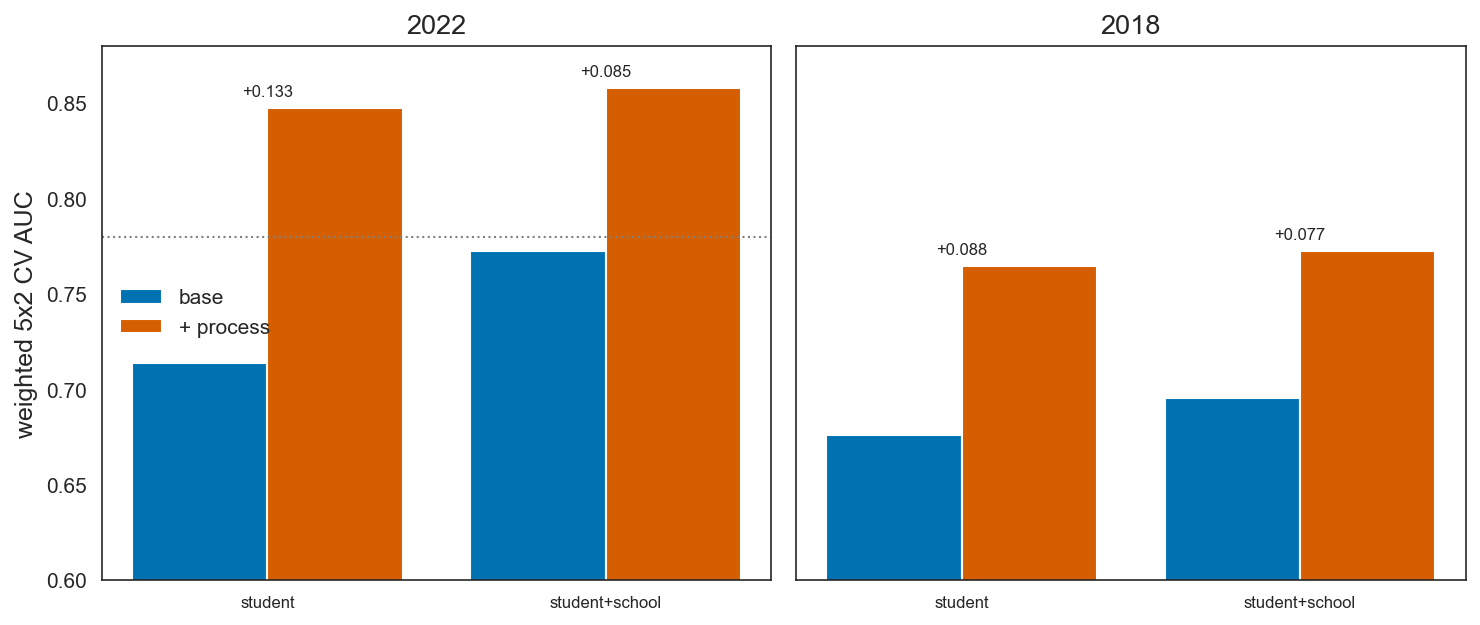

In [12]:
comb = abl[abl.modality=='cognitive+questionnaire']
fig, axes = plt.subplots(1,2, figsize=(10,4.3), sharey=True)
for ax, cyc in zip(axes,(2022,2018)):
    t = comb[comb.cycle==cyc]; x=np.arange(len(t))
    ax.bar(x-0.2, t.base_auc, 0.4, label='base', color=PALETTE['blue'])
    ax.bar(x+0.2, t.process_auc, 0.4, label='+ process', color=PALETTE['vermilion'])
    for i,r in enumerate(t.itertuples()):
        ax.text(i, max(r.base_auc,r.process_auc)+0.006, f'{r.lift:+.3f}', ha='center', fontsize=8)
    ax.set_xticks(x); ax.set_xticklabels(t.baseline, fontsize=8); ax.set_title(str(cyc)); ax.set_ylim(0.6,0.88)
    if cyc==2022: ax.axhline(0.78, ls=':', color='0.5', lw=1)
axes[0].set_ylabel('weighted 5x2 CV AUC'); axes[0].legend(frameon=False)
plt.tight_layout(); plt.show()

**Reading:** adding process features lifts the AUC at every baseline. At the headline student+school ceiling the 2022 AUC rises **0.773 -> 0.858 (+8.5 pp, p < 0.001)**, and 0.696 -> 0.773 in 2018. So the ceiling that a decade of questionnaire features could not break is *not* an absolute limit - a different data modality carries real extra signal. The next section asks whether that signal is one we could ever actually screen with.

### 2. Decomposition: is the lift deployable, or an artefact of taking the test?

The lift splits into two very different modalities. Cognitive process is measured *from the math test itself* - it is endogenous to the ability being predicted and only exists *after* a student sits the CBA. Questionnaire timing is a separate instrument, available without the cognitive test.

In [13]:
dec = abl[(abl.cycle==2022)&(abl.baseline=='student+school')]
dec[['modality','base_auc','process_auc','lift','lift_p','n_proc_feats']].round(4)

,modality,base_auc,process_auc,lift,lift_p,n_proc_feats
1,cognitive+questionnaire,0.7728,0.8579,0.0851,0.000,15
2,cognitive-only,0.7728,0.8508,0.0780,0.000,10
3,questionnaire-only,0.7728,0.7842,0.0114,0.019,5


**Reading:** the +8.5 pp is almost entirely **cognitive process** (+7.8 pp on its own). The **questionnaire-timing** modality - the only slice usable *before* the test, i.e. the only one a real screener could deploy - adds just **+1.1 pp** (p = 0.019). So a new modality moves the *number*, but the movement is post-hoc process data that (a) is endogenous to proficiency and (b) cannot flag a student early. The **deployable screening ceiling essentially holds at ~0.78**.

### 3. What the model uses: pure timing

LightGBM importance over the process features (explanatory fit, 2022 student+school).

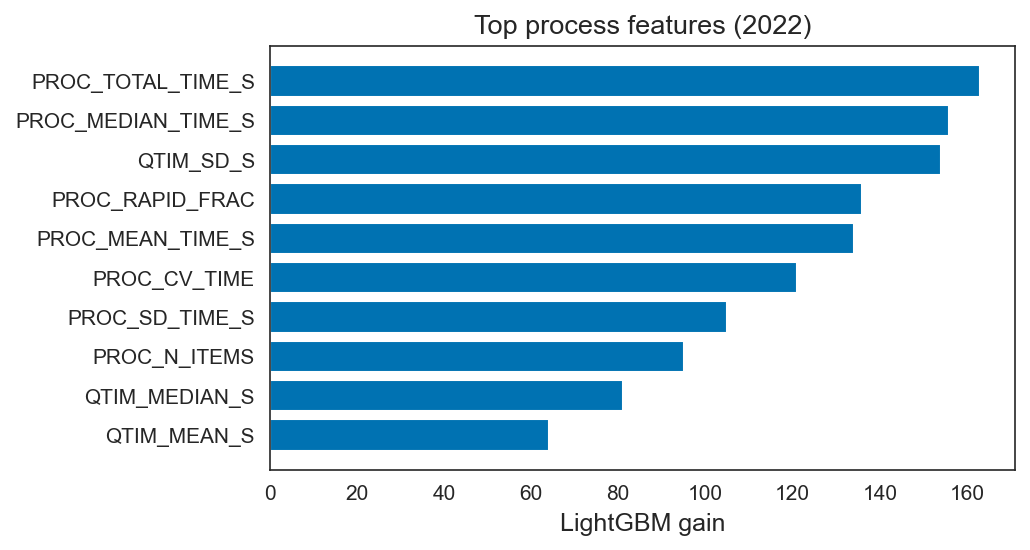

In [14]:
ip = imp[imp.index.str.startswith(('PROC_','QTIM_'))].head(10)
fig, ax = plt.subplots(figsize=(7,3.8))
ax.barh(ip.index[::-1], ip['gain'].values[::-1], color=PALETTE['blue'])
ax.set_xlabel('LightGBM gain'); ax.set_title('Top process features (2022)')
plt.tight_layout(); plt.show()

**Reading:** total and median time-on-task, rapid-response fraction and pacing variability dominate - the model reads *how* a student worked through the test. These are exactly the endogenous, post-hoc signals from section 2: informative about ability, useless as an early-warning screen.

### Conclusions & Interpretation

- **A new modality does move the ceiling** - CBA process data lifts the 2022 AUC to **0.86**, the first thing in the project to break 0.78. The ceiling is not an absolute information limit.
- **But the movement is not deployable.** ~90% of the lift is cognitive-test process data, which is endogenous to the proficiency it predicts and only observable after the assessment. It cannot screen a student in advance.
- **The screening ceiling holds.** The only pre-test modality (questionnaire response latency) adds +1.1 pp - real but marginal. For the paper's actual use case - flagging at-risk students from background data - ~0.78 stands.
- **This sharpens, not contradicts, the data-ceiling thesis.** The ceiling is about *what is knowable before the test*. Rich behavioural signal exists inside the test, but harvesting it requires administering the very assessment a screener is meant to anticipate. Reported honestly, including the large cognitive-process lift we cannot use.